In [1]:
import sys
print(sys.executable)

C:\Users\2023\anaconda3\envs\trustxai\python.exe


In [2]:
import os
import joblib
import shap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print("Libraries Loaded Successfully.")

C:\Users\2023\anaconda3\envs\trustxai\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Libraries Loaded Successfully.


In [3]:
PROJECT_ROOT = r"D:\TrustXAI"

MODEL_PATH = os.path.join(
    PROJECT_ROOT,
    "models",
    "Improved_RandomForest_TrustXAI.pkl"
)

DATA_PATH = os.path.join(
    PROJECT_ROOT,
    "data",
    "ready",
    "TrustXAI_Balanced.csv"
)

RESULT_PATH = os.path.join(
    PROJECT_ROOT,
    "results"
)

os.makedirs(RESULT_PATH, exist_ok=True)

print("Paths Ready.")

Paths Ready.


In [4]:
print("Loading Random Forest Model...")

rf_model = joblib.load(MODEL_PATH)

print("Loading Dataset...")

df = pd.read_csv(DATA_PATH)

print("Dataset Shape:", df.shape)

df.head()

Loading Random Forest Model...
Loading Dataset...
Dataset Shape: (49115, 85)


,Flow ID,Source IP,Source Port,Destination IP,Destination Port,Protocol,Timestamp,Flow Duration,Total Fwd Packets,Total Backward Packets,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,192.168.10.5-104.97.125.160-55110-443-6,104.97.125.160,443.0,192.168.10.5,55110.0,6.0,7/7/2017 3:33,318.0,3.0,0.0,...,20.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
1,192.168.10.5-104.97.125.160-55110-443-6,192.168.10.5,55110.0,104.97.125.160,443.0,6.0,7/7/2017 3:32,63552406.0,7.0,2.0,...,20.0,77777.0,0.0,77777.0,77777.0,58500000.0,0.0,58500000.0,58500000.0,0
2,192.168.10.12-61.251.165.12-36452-80-6,192.168.10.12,36452.0,61.251.165.12,80.0,6.0,7/7/2017 3:51,135.0,2.0,0.0,...,32.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
3,192.168.10.3-192.168.10.5-53-53173-17,192.168.10.5,53173.0,192.168.10.3,53.0,17.0,7/7/2017 3:45,209.0,2.0,2.0,...,20.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
4,192.168.10.15-64.34.226.87-58732-443-6,64.34.226.87,443.0,192.168.10.15,58732.0,6.0,7/7/2017 3:57,158.0,1.0,1.0,...,20.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0


In [5]:
columns_to_remove = [
    "Flow ID",
    "Source IP",
    "Destination IP",
    "Timestamp"
]

X = df.drop(columns=columns_to_remove + ["Label"], errors="ignore")
y = df["Label"]

print("Features Shape :", X.shape)
print("Labels Shape   :", y.shape)
print("Number of Features:", X.shape[1])

Features Shape : (49115, 80)
Labels Shape   : (49115,)
Number of Features: 80


In [6]:
sample = X.sample(
    n=300,
    random_state=42
)

print("Sample Shape:", sample.shape)

Sample Shape: (300, 80)


In [7]:
print("Creating SHAP Explainer...")

explainer = shap.TreeExplainer(rf_model)

print("Calculating SHAP Values...")

shap_values = explainer(sample)

print("SHAP Values Ready!")

Creating SHAP Explainer...
Calculating SHAP Values...
SHAP Values Ready!


In [8]:
print(type(shap_values))
print(shap_values.values.shape)

<class 'shap._explanation.Explanation'>
(300, 80, 12)


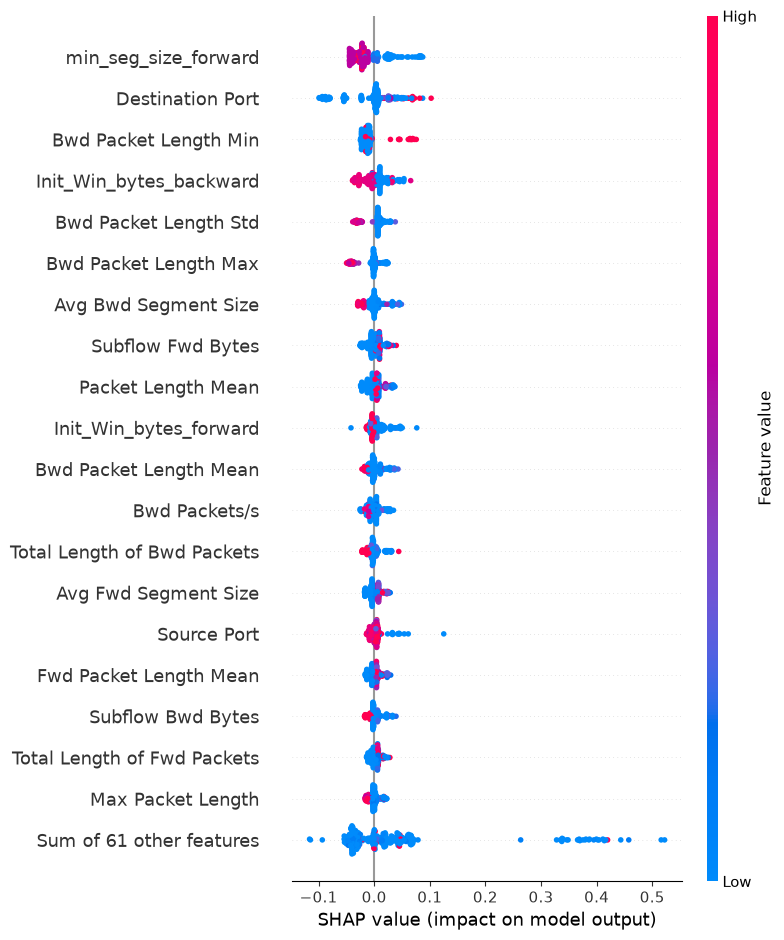

SHAP Summary Plot Saved Successfully!


In [9]:
plt.figure(figsize=(12,8))

shap.plots.beeswarm(
    shap_values[:, :, 0],
    max_display=20,
    show=False
)

plt.tight_layout()

plt.savefig(
    os.path.join(
        RESULT_PATH,
        "SHAP_Summary_Beeswarm.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("SHAP Summary Plot Saved Successfully!")

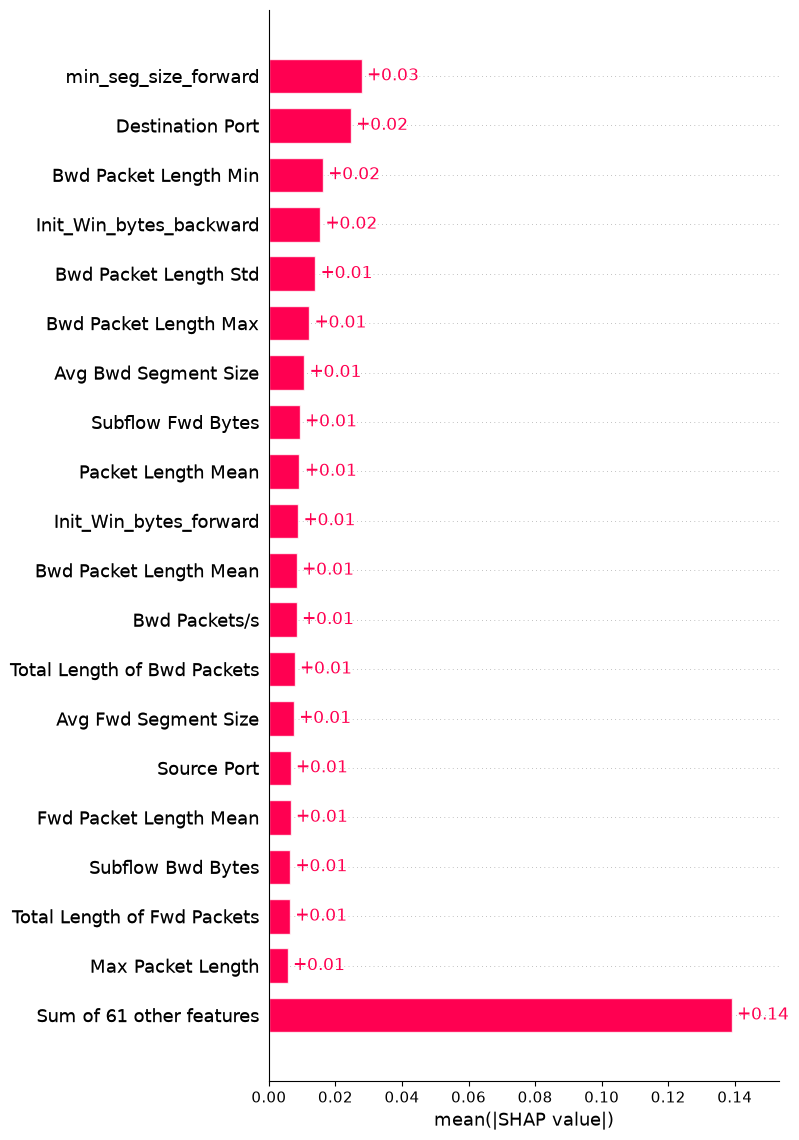

SHAP Feature Importance Saved Successfully!


In [10]:
plt.figure(figsize=(12,8))

shap.plots.bar(
    shap_values[:, :, 0],
    max_display=20,
    show=False
)

plt.tight_layout()

plt.savefig(
    os.path.join(
        RESULT_PATH,
        "SHAP_Feature_Importance.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("SHAP Feature Importance Saved Successfully!")

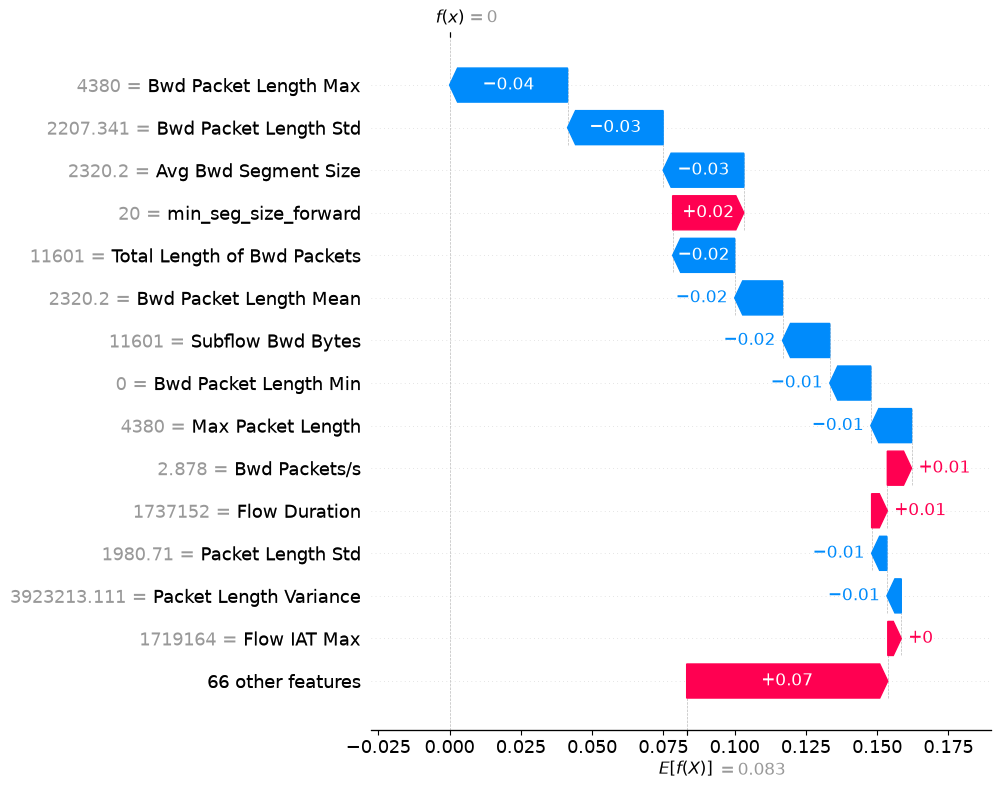

Waterfall Plot Completed.


In [11]:
sample_index = 0

shap.plots.waterfall(
    shap_values[sample_index, :, 0],
    max_display=15,
    show=True
)

print("Waterfall Plot Completed.")

In [12]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "MeanAbsSHAP": np.abs(shap_values[:, :, 0].values).mean(axis=0)
})

importance = importance.sort_values(
    by="MeanAbsSHAP",
    ascending=False
)

importance.to_csv(
    os.path.join(
        RESULT_PATH,
        "SHAP_Feature_Importance.csv"
    ),
    index=False
)

print(importance.head(20))
print("CSV Saved Successfully.")

                        Feature  MeanAbsSHAP
71         min_seg_size_forward     0.027853
1              Destination Port     0.024606
13        Bwd Packet Length Min     0.016190
69      Init_Win_bytes_backward     0.015365
15        Bwd Packet Length Std     0.013911
12        Bwd Packet Length Max     0.012092
56         Avg Bwd Segment Size     0.010580
65            Subflow Fwd Bytes     0.009241
42           Packet Length Mean     0.009194
68       Init_Win_bytes_forward     0.008781
14       Bwd Packet Length Mean     0.008350
39                Bwd Packets/s     0.008332
7   Total Length of Bwd Packets     0.007733
55         Avg Fwd Segment Size     0.007475
0                   Source Port     0.006503
10       Fwd Packet Length Mean     0.006500
67            Subflow Bwd Bytes     0.006361
6   Total Length of Fwd Packets     0.006280
41            Max Packet Length     0.005622
17               Flow Packets/s     0.005524
CSV Saved Successfully.


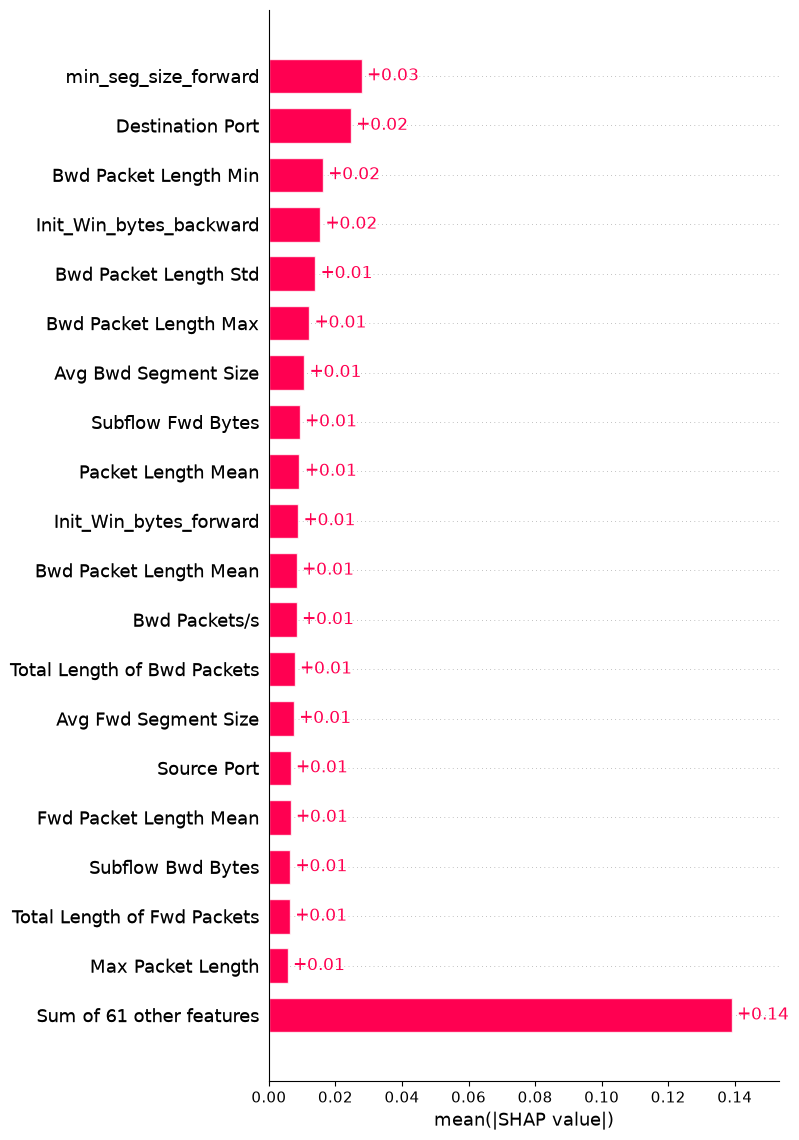

Bar Plot Saved Successfully!


In [13]:
plt.figure(figsize=(12,8))

shap.plots.bar(
    shap_values[:, :, 0],
    max_display=20,
    show=False
)

plt.tight_layout()

plt.savefig(
    os.path.join(
        RESULT_PATH,
        "SHAP_BarPlot.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Bar Plot Saved Successfully!")

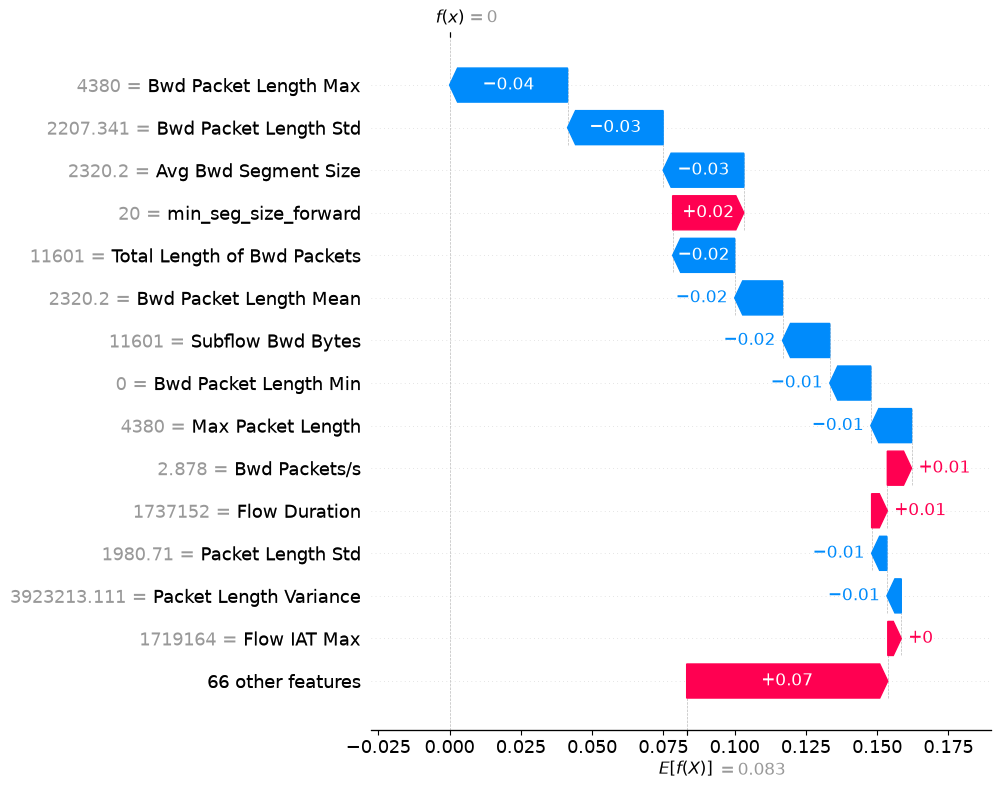

In [14]:
sample_index = 0

shap.plots.waterfall(
    shap_values[sample_index, :, 0],
    max_display=15,
    show=True
)

In [15]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "MeanAbsSHAP": np.abs(shap_values[:, :, 0].values).mean(axis=0)
})

importance = importance.sort_values(
    by="MeanAbsSHAP",
    ascending=False
)

importance.to_csv(
    os.path.join(
        RESULT_PATH,
        "SHAP_FeatureImportance.csv"
    ),
    index=False
)

importance.head(20)

,Feature,MeanAbsSHAP
71,min_seg_size_forward,0.027853
1,Destination Port,0.024606
13,Bwd Packet Length Min,0.016190
69,Init_Win_bytes_backward,0.015365
15,Bwd Packet Length Std,0.013911
12,Bwd Packet Length Max,0.012092
56,Avg Bwd Segment Size,0.010580
65,Subflow Fwd Bytes,0.009241
42,Packet Length Mean,0.009194
68,Init_Win_bytes_forward,0.008781
